In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
# Load Heart Disease Dataset

df = pd.read_csv("heart_disease_uci.csv")

# Display first 5 rows
print(df.head())

# Display dataset dimensions
print("Dataset Shape:", df.shape)

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  
Dataset 

In [25]:
# Display dataset information

print(df.info())

# Display statistical summary

print(df.describe())

# Display column names

print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  

In [26]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

# Remove duplicate rows if any

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Shape after removing duplicates: (920, 16)


In [29]:
# Convert the target variable 'num' into binary format.
# 0 = No Heart Disease
# 1 = Heart Disease

df['num'] = df['num'].apply(
    lambda x: 0 if x == 0 else 1
)

# Check class distribution.

print(df['num'].value_counts())

num
1    509
0    411
Name: count, dtype: int64


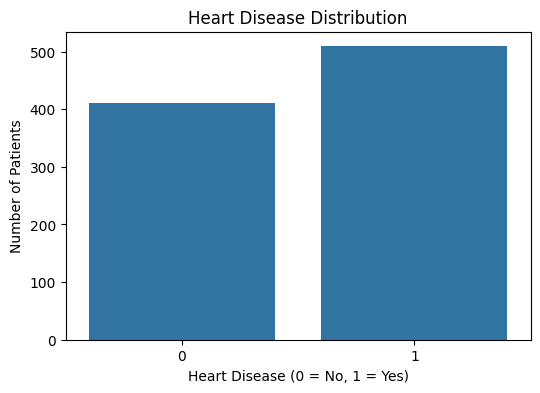

In [30]:
# Visualize the number of patients with and without heart disease.

plt.figure(figsize=(6,4))

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

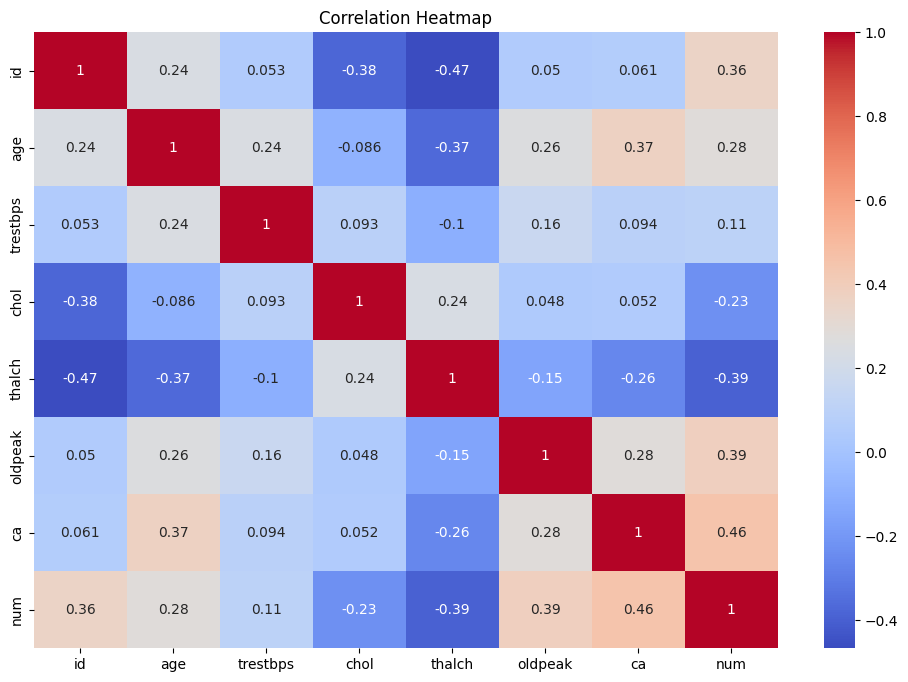

In [31]:
# Display correlations among numerical features.
# This helps identify features that strongly influence
# the target variable.

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

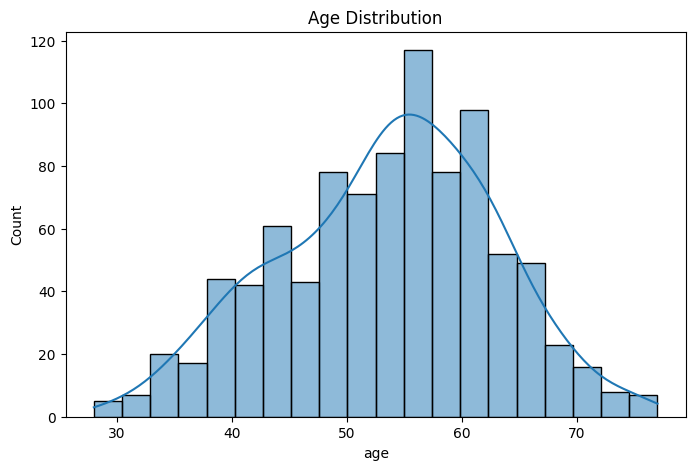

In [32]:
# Visualize the distribution of patient ages.

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

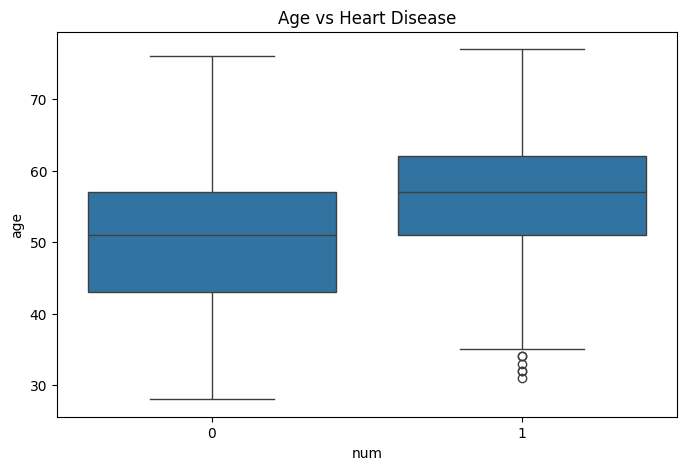

In [33]:
# Compare age distribution between patients
# with and without heart disease.

plt.figure(figsize=(8,5))

sns.boxplot(
    x='num',
    y='age',
    data=df
)

plt.title("Age vs Heart Disease")

plt.show()

In [34]:
# Separate independent variables (features)
# and dependent variable (target).

X = df.drop('num', axis=1)

y = df['num']

In [36]:
# Convert categorical variables into numerical format
# using one-hot encoding.

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(920, 22)


In [39]:
# Split the dataset into training and testing sets.
# 80% data is used for training and 20% for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [40]:
# Standardize feature values to improve
# Logistic Regression performance.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [44]:
# Create and train a Logistic Regression model.

from sklearn.impute import SimpleImputer

# Impute NaN values in X_train and X_test
# Use median strategy for numerical data to handle missing values robustly
imputer = SimpleImputer(strategy='median')

# Fit imputer on X_train and transform both X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_imputed, # Use the imputed data
    y_train
)

print("Model Training Completed")

Model Training Completed


In [46]:
# Predict heart disease status on test data.

predictions = model.predict(X_test_imputed) # Use X_test_imputed instead of X_test

print(predictions[:10])

[0 0 1 1 1 0 0 1 1 0]


In [49]:
# Calculate overall prediction accuracy.

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.842391304347826


In [50]:
# Display Precision, Recall, F1-Score,
# and Support for each class.

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        75
           1       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



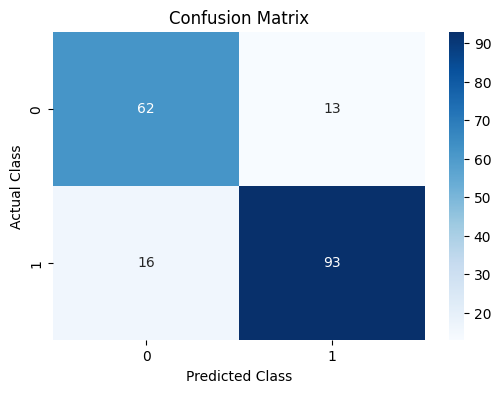

In [51]:
# Generate and visualize the confusion matrix
# to evaluate prediction performance.

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

ROC-AUC Score: 0.9135168195718655


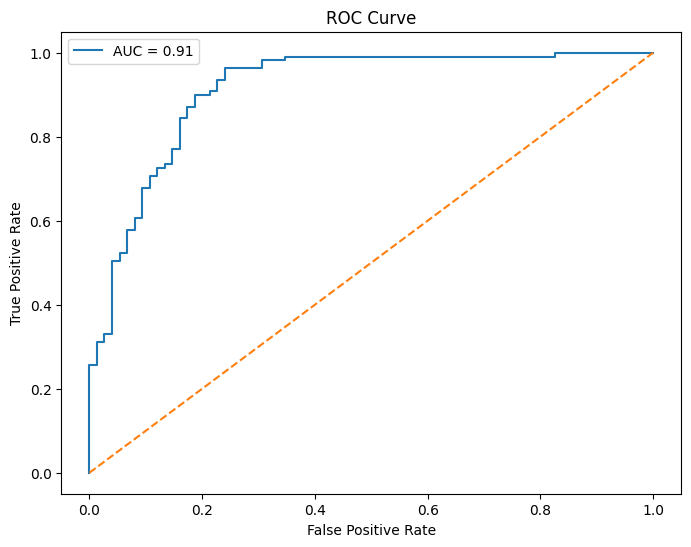

In [53]:
# Calculate prediction probabilities and ROC-AUC score.
# ROC Curve shows the model's ability to distinguish classes.

y_prob = model.predict_proba(X_test_imputed)[:,1] # Use X_test_imputed

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", auc_score)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [54]:
# Extract feature coefficients from Logistic Regression.
# Larger coefficient values indicate stronger influence.

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
0                         id    2.019038
6                         ca    1.026330
5                    oldpeak    0.633069
7                   sex_Male    0.575399
17                exang_True    0.381882
18                slope_flat    0.289455
21    thal_reversable defect    0.240289
2                   trestbps    0.081844
3                       chol    0.079090
14                  fbs_True    0.059977
16  restecg_st-t abnormality   -0.009613
4                     thalch   -0.015630
1                        age   -0.022382
9        dataset_Switzerland   -0.034285
15            restecg_normal   -0.090323
19           slope_upsloping   -0.155168
20               thal_normal   -0.189967
13         cp_typical angina   -0.314528
12            cp_non-anginal   -0.479296
11        cp_atypical angina   -0.695353
8            dataset_Hungary   -0.846901
10     dataset_VA Long Beach   -1.488087


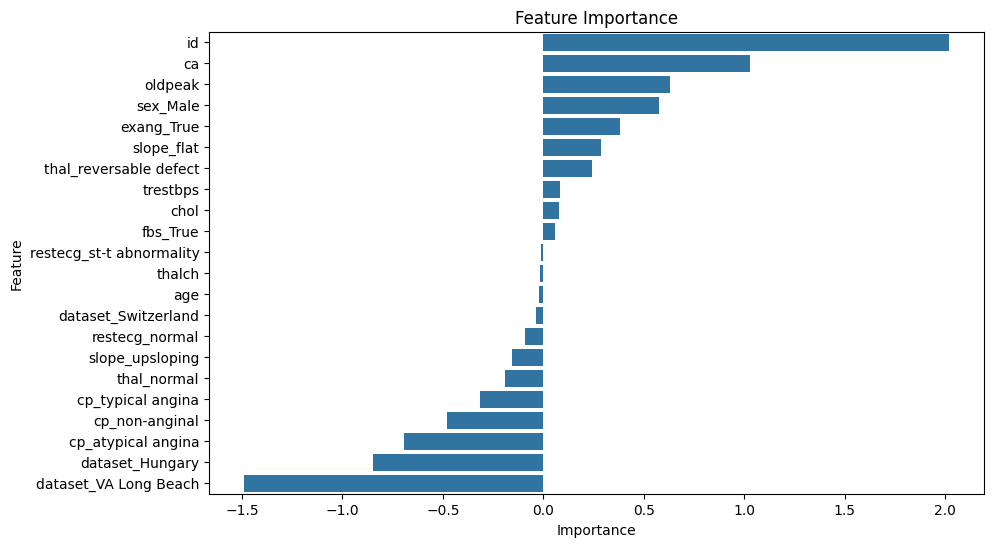

In [55]:
# Visualize the most important features affecting prediction.

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()